<a href="https://colab.research.google.com/github/239y1a3931-sudo/Machain-Learning/blob/main/day11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ■■ Feature Importance: Plot + Feature Selection ■■
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_diabetes # regression dataset repurposed as classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import pandas as pd, numpy as np, matplotlib.pyplot as plt


In [ ]:
# Use the diabetes (Pima Indians) dataset

import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Download the dataset if it's not present
if not os.path.exists('diabetes.csv'):
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

# Load dataset
df = pd.read_csv('diabetes.csv')

# Replace 0 values with median
fix_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in fix_cols:
    df[col] = df[col].replace(0, df[col].median())

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42)

# Train model
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:

# ■■ Feature importances ■■
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importances (higher = more important):')
print(imp.round(3))

Feature Importances (higher = more important):
Glucose                     0.259
BMI                         0.163
Age                         0.147
DiabetesPedigreeFunction    0.117
BloodPressure               0.088
Pregnancies                 0.078
Insulin                     0.076
SkinThickness               0.071
dtype: float64


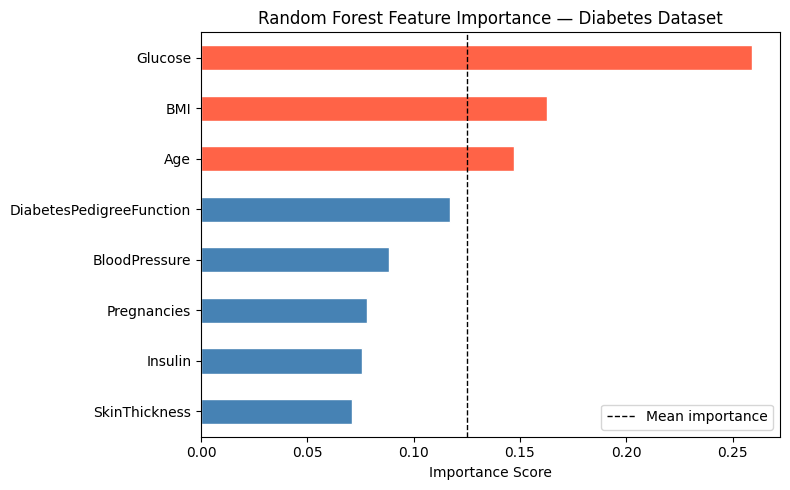

In [ ]:
# ■■ Bar chart ■■
imp_sorted = imp.sort_values() # ascending for barh
colors = ['tomato' if v > imp.mean() else 'steelblue' for v in imp_sorted]
imp_sorted.plot(kind='barh', color=colors, figsize=(8,5), edgecolor='white')
plt.axvline(x=imp.mean(), color='black', linestyle='--', linewidth=1, label='Mean importance')
plt.title('Random Forest Feature Importance — Diabetes Dataset', fontsize=12)
plt.xlabel('Importance Score'); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ■■ Feature Selection: keep only top features ■■
top_features = imp[imp > imp.mean()].index.tolist()
print(f'\nTop features (above average): {top_features}')
rf_top = RandomForestClassifier(n_estimators=200, random_state=42)
rf_top.fit(X_train[top_features], y_train)
full_acc = rf.score(X_test, y_test)
top_acc = rf_top.score(X_test[top_features], y_test)
print(f'Accuracy with all {len(X.columns)} features : {full_acc:.2%}')
print(f'Accuracy with top {len(top_features)} features : {top_acc:.2%}')
print('Often comparable — low-importance features can add noise!')


Top features (above average): ['Glucose', 'BMI', 'Age']
Accuracy with all 8 features : 77.27%
Accuracy with top 3 features : 72.73%
Often comparable — low-importance features can add noise!


In [ ]:
# ■■ OOB Score + n_estimators Sweep ■■
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np, matplotlib.pyplot as plt, time

X, y = make_classification(n_samples=1000, n_features=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# ■■ Demo 1: OOB Score (free validation from bootstrap) ■■
rf_oob = RandomForestClassifier(n_estimators=10, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print(f'OOB Score : {rf_oob.oob_score_:.2%} ← estimated on ~37% unseen rows per tree')
print(f'Test Score : {rf_oob.score(X_test, y_test):.2%} ← actual held-out test')
print('OOB score is a free estimate — no need for a separate validation set!')

OOB Score : 85.25% ← estimated on ~37% unseen rows per tree
Test Score : 92.50% ← actual held-out test
OOB score is a free estimate — no need for a separate validation set!


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


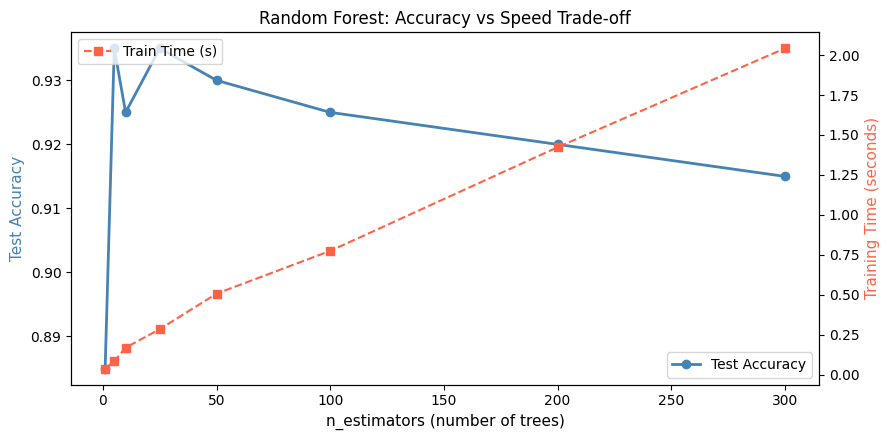

In [ ]:
# ■■ Demo 2: How n_estimators affects accuracy and speed ■■
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 300]
accs, times = [], []
for n in n_trees_list:
  t0 = time.time()
  rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
  rf.fit(X_train, y_train)
  accs.append(accuracy_score(y_test, rf.predict(X_test)))
  times.append(time.time() - t0)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
ax1.plot(n_trees_list, accs, 'o-', color='steelblue', lw=2, label='Test Accuracy')
ax2.plot(n_trees_list, times, 's--', color='tomato', lw=1.5, label='Train Time (s)')
ax1.set_xlabel('n_estimators (number of trees)', fontsize=11)
ax1.set_ylabel('Test Accuracy', color='steelblue', fontsize=11)
ax2.set_ylabel('Training Time (seconds)', color='tomato', fontsize=11)
ax1.set_title('Random Forest: Accuracy vs Speed Trade-off')
ax1.legend(loc='lower right'); ax2.legend(loc='upper left')
plt.tight_layout(); plt.show()
# INSIGHT: Accuracy stabilises quickly (~50-100 trees); time grows linearly
# There's a 'sweet spot' — more trees don't help much but cost more time1`